<a href="https://colab.research.google.com/github/Apekshya175/AI-ML/blob/main/Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries and Set Random Seed

In [ ]:


import os
import re
import time
import random
import pickle
import contractions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import gensim.downloader as api
import gradio as gr

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/apekshya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/apekshya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/apekshya/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
I0000 00:00:1778406311.050438    6167 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778406312.720540    6167 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778406316.

TensorFlow version: 2.21.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Load the News Category Dataset

In [ ]:
DATA_PATH = "6. News Category Dataset-20260509T130857Z-3-001/6. News Category Dataset/news_category.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Dataset shape: (11025, 2)


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


Check Dataset Columns and Basic Information

In [ ]:
print("Columns in dataset:")
print(df.columns.tolist())

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Columns in dataset:
['headline', 'category']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11025 entries, 0 to 11024
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  11025 non-null  object
 1   category  11025 non-null  object
dtypes: object(2)
memory usage: 172.4+ KB
None

Missing values:
headline    0
category    0
dtype: int64

Duplicate rows: 78


Select Text and Label Columns

In [ ]:
TEXT_COLUMN = "headline"
LABEL_COLUMN = "category"

# Keep only required columns
df = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()

# Remove missing and duplicate records
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Convert text and labels to string type
df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str)
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str)

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (10947, 2)


Dataset Class Distribution

Number of classes: 5

Class distribution:
category
SPORTS            5076
TECH              2049
MONEY             1754
CULTURE & ARTS    1054
EDUCATION         1014
Name: count, dtype: int64


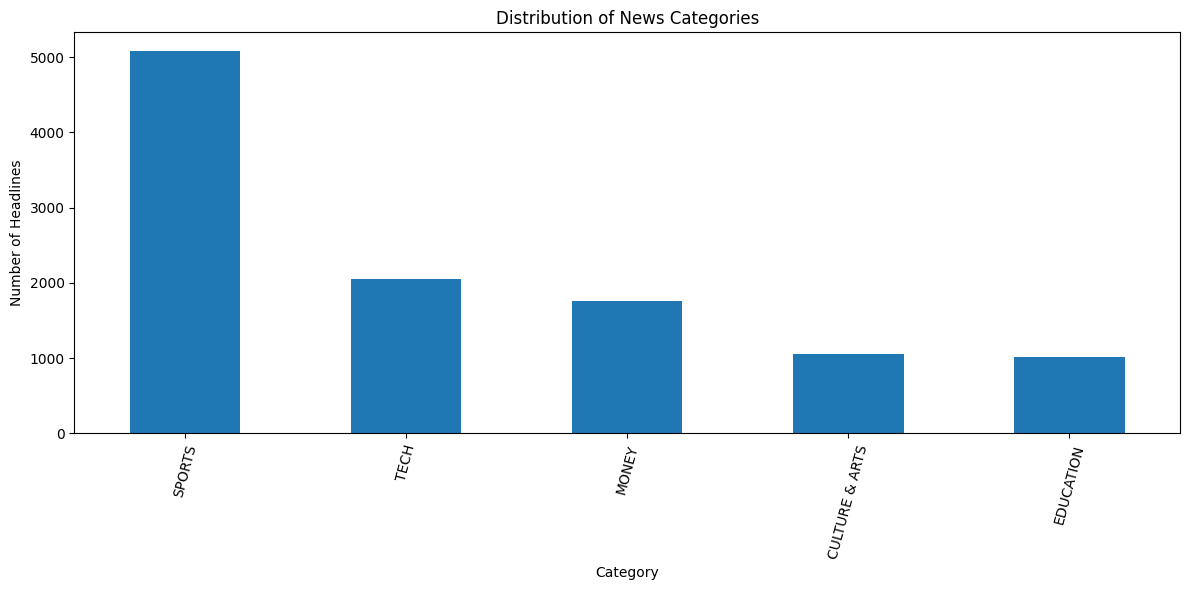

In [ ]:
class_counts = df[LABEL_COLUMN].value_counts()

print("Number of classes:", df[LABEL_COLUMN].nunique())
print("\nClass distribution:")
print(class_counts)

plt.figure(figsize=(12, 6))
class_counts.plot(kind="bar")
plt.title("Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Number of Headlines")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

Text Length Analysis Before Cleaning

count    10947.000000
mean         9.781858
std          2.998280
min          1.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         28.000000
Name: raw_word_count, dtype: float64


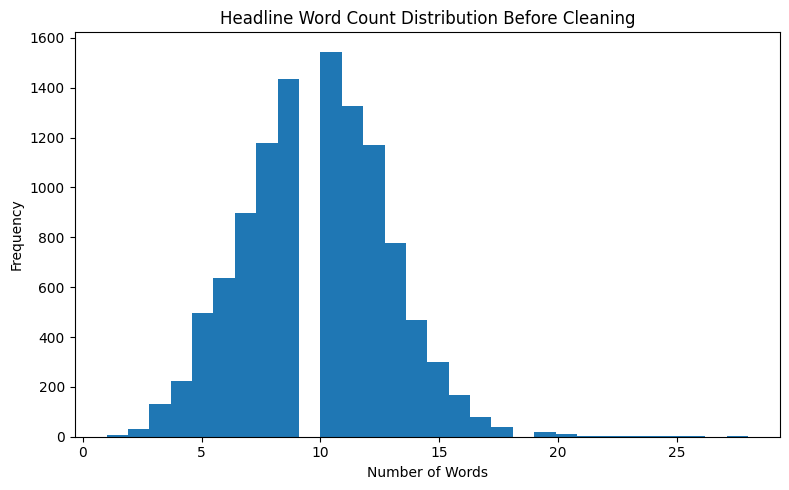

In [ ]:
df["raw_word_count"] = df[TEXT_COLUMN].apply(lambda x: len(x.split()))

print(df["raw_word_count"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["raw_word_count"], bins=30)
plt.title("Headline Word Count Distribution Before Cleaning")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Define Text Cleaning Function

In [ ]:


stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Clean a single text headline using standard NLP preprocessing steps.
    """
    # Convert to lowercase
    text = text.lower()

    # Expand contractions such as "don't" to "do not"
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove mentions and hashtags symbols
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove special characters and punctuation
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize manually using split
    words = text.split()

    # Remove stopwords and lemmatize
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 1
    ]

    return " ".join(cleaned_words)

Apply Text Cleaning

In [ ]:

# The cleaned headlines will be used for tokenization and model training.

df["cleaned_headline"] = df[TEXT_COLUMN].apply(clean_text)

# Remove rows that became empty after cleaning
df = df[df["cleaned_headline"].str.strip() != ""].copy()

print("Dataset shape after text cleaning:", df.shape)

display(df[[TEXT_COLUMN, "cleaned_headline", LABEL_COLUMN]].head(10))

Dataset shape after text cleaning: (10947, 4)


,headline,cleaned_headline,category
0,How A New Documentary Captures The Complexity ...,new documentary capture complexity child immig...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,twitch ban gambling site streamer scam folk,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,reboot clever navel gazey look inside tv reboots,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury will base stealing shortstop dodger dy,SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",la vega ace win first wnba title chelsea gray ...,SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",meet alex aster tiktoker changing publishing i...,CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,tiktok search result riddled misinformation re...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,boston marathon make race inclusive nonbinary ...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",anthony varvaro mlb pitcher turned transit cop...,SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,ani liu brilliantly disguising art science,CULTURE & ARTS


Most Frequent Words Visualization

,Word,Frequency
0,video,481
1,new,457
2,photo,452
3,game,366
4,nfl,363
5,world,318
6,player,310
7,school,286
8,win,271
9,year,271


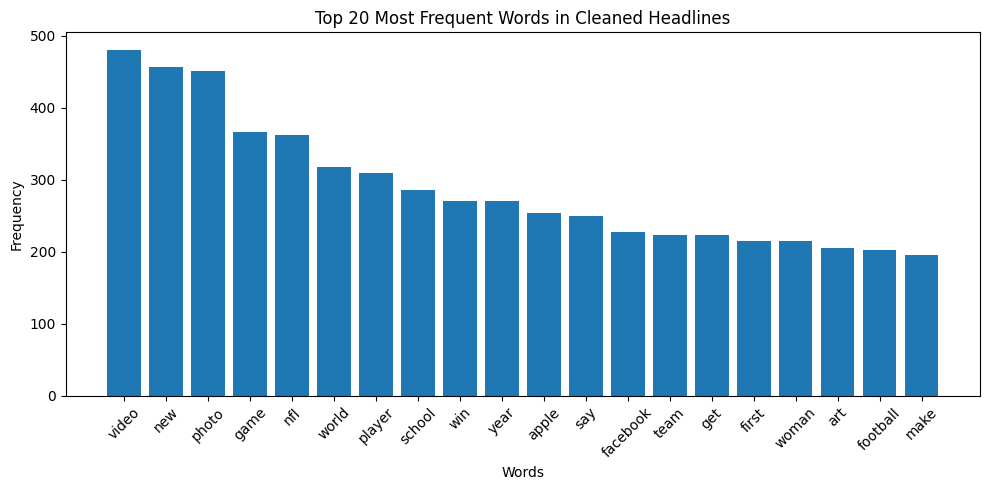

In [ ]:

# This gives a simple understanding of the most common words appearing in the news headlines.

all_words = " ".join(df["cleaned_headline"]).split()
word_freq = Counter(all_words)

common_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

display(common_words)

plt.figure(figsize=(10, 5))
plt.bar(common_words["Word"], common_words["Frequency"])
plt.title("Top 20 Most Frequent Words in Cleaned Headlines")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Word Cloud Visualization

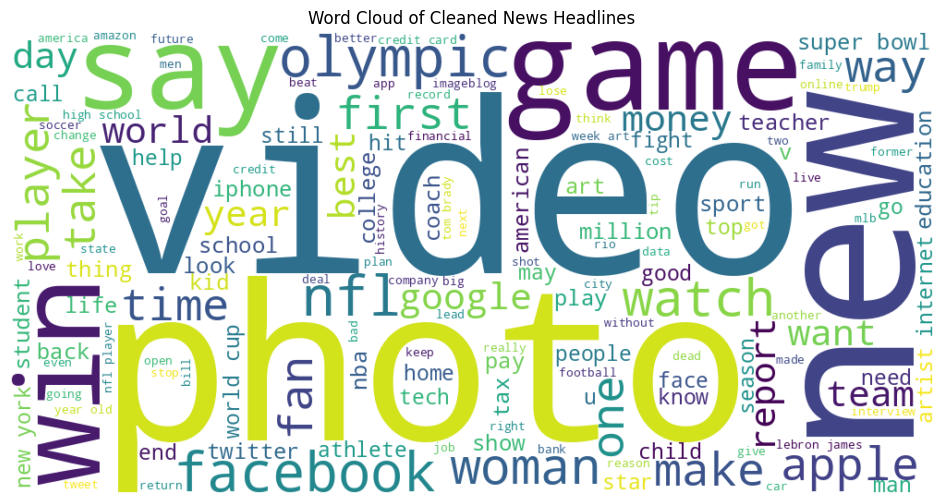

In [ ]:
text_for_wordcloud = " ".join(df["cleaned_headline"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=150
).generate(text_for_wordcloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned News Headlines")
plt.show()

Encode Target Labels

In [ ]:

label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df[LABEL_COLUMN])

class_names = label_encoder.classes_
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Class names:")
for i, label in enumerate(class_names):
    print(i, ":", label)

y = to_categorical(df["label_encoded"], num_classes=num_classes)

print("One-hot encoded label shape:", y.shape)

Number of classes: 5
Class names:
0 : CULTURE & ARTS
1 : EDUCATION
2 : MONEY
3 : SPORTS
4 : TECH
One-hot encoded label shape: (10947, 5)


Train-Test Split

In [ ]:

# Stratification is used to preserve class distribution in both sets.

X = df["cleaned_headline"].values
y_labels = df["label_encoded"].values

X_train_text, X_test_text, y_train_labels, y_test_labels = train_test_split(
    X,
    y_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=y_labels
)

y_train = to_categorical(y_train_labels, num_classes=num_classes)
y_test = to_categorical(y_test_labels, num_classes=num_classes)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Training samples: 8757
Testing samples: 2190
y_train shape: (8757, 5)
y_test shape: (2190, 5)


Tokenization

In [ ]:
MAX_WORDS = 20000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index) + 1)

print("Total unique words:", len(word_index))
print("Vocabulary size used:", vocab_size)
print("Example sequence:", X_train_seq[0])

Total unique words: 11338
Vocabulary size used: 11339
Example sequence: [184, 65, 5615, 5616]


Percentile-Based Padding

In [ ]:

# Instead of using the maximum length, 95th percentile is used to avoid excessively long outlier headlines.

train_lengths = [len(seq) for seq in X_train_seq]

MAX_LEN = int(np.percentile(train_lengths, 95))

# Safety rule: headline datasets can be short, so keep a minimum length
MAX_LEN = max(MAX_LEN, 10)

print("95th percentile sequence length:", MAX_LEN)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

95th percentile sequence length: 11
X_train_pad shape: (8757, 11)
X_test_pad shape: (2190, 11)


Save Tokenizer and Label Encoder

In [ ]:
# Save Tokenizer and Label Encoder

os.makedirs("outputs_part3", exist_ok=True)

with open("outputs_part3/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("outputs_part3/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Tokenizer and label encoder saved successfully.")

Tokenizer and label encoder saved successfully.


Define Training Callbacks

In [ ]:

def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"outputs_part3/{model_name}.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

Helper Function to Plot Training History

In [ ]:
# This function plots training and validation accuracy/loss curves.

def plot_training_history(history, model_name):
    # Accuracy plot
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"outputs_part3/{model_name}_accuracy.png", dpi=300)
    plt.show()

    # Loss plot
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"outputs_part3/{model_name}_loss.png", dpi=300)
    plt.show()

Helper Function for Model Evaluation

In [ ]:

results = []

def evaluate_model(model, model_name, X_test_data, y_test_labels):
    print("=" * 70)
    print(f"Evaluation Results for {model_name}")
    print("=" * 70)

    y_prob = model.predict(X_test_data)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test_labels, y_pred)
    print(f"Test Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test_labels,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    cm = confusion_matrix(y_test_labels, y_pred)

    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(cmap=None, xticks_rotation=75, values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.savefig(f"outputs_part3/{model_name}_confusion_matrix.png", dpi=300)
    plt.show()

    return acc, y_pred, y_prob

Model 1: Simple RNN with Trainable Embedding

Build Model 1: Simple RNN

In [ ]:

# Simple RNN with Trainable Embedding

EMBEDDING_DIM = 100

model_1_rnn = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),
    SimpleRNN(64),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_1_rnn.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_1_rnn.summary()

/home/apekshya/tf/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1778406383.092143    6167 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3554 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train Model 1

In [ ]:

# The baseline model is trained using early stopping and validation split.

start_time = time.time()

history_1 = model_1_rnn.fit(
    X_train_pad,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=64,
    callbacks=get_callbacks("model_1_simple_rnn"),
    verbose=1
)

model_1_time = time.time() - start_time

print(f"Model 1 training time: {model_1_time:.2f} seconds")

Epoch 1/20


I0000 00:00:1778406386.273256    7235 service.cc:153] XLA service 0x7aaccc047020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778406386.273307    7235 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 12.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778406386.465341    7235 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778406386.980299    7235 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778406387.106103    7235 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1858_grad_2142_const_0__.28.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778406387.108265    7235 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2708__.31
I0000 00:00:1778406387.231293    7235 dot_search_space.cc:240] All configs were f

  8/110 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2565 - loss: 1.5913

I0000 00:00:1778406398.110705    7235 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4406 - loss: 1.3741

I0000 00:00:1778406400.266161    7234 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1858_grad_2142_const_0__.28.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778406400.266351    7234 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2708__.31
I0000 00:00:1778406400.359858    7234 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778406401.148810    7398 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_24', 52 bytes spill stores, 52 bytes spill loads

I0000 00:00:1778406401.177828    7396 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_24', 12 bytes spill stores, 12 bytes spi

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4421 - loss: 1.3707

I0000 00:00:1778406409.917571    7234 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778406412.629114    7233 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778406413.416125    7552 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_10', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1778406413.589799    7233 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Work


Epoch 1: val_loss improved from None to 0.88574, saving model to outputs_part3/model_1_simple_rnn.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 32s 162ms/step - accuracy: 0.5188 - loss: 1.1891 - val_accuracy: 0.6427 - val_loss: 0.8857 - learning_rate: 0.0010
Epoch 2/20
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7111 - loss: 0.7262
Epoch 2: val_loss improved from 0.88574 to 0.62835, saving model to outputs_part3/model_1_simple_rnn.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7657 - loss: 0.6074 - val_accuracy: 0.7751 - val_loss: 0.6284 - learning_rate: 0.0010
Epoch 3/20
106/110 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8947 - loss: 0.3153
Epoch 3: val_loss did not improve from 0.62835
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9166 - loss: 0.2567 - val_accuracy: 0.8002 - val_loss: 0.6789 - learning_rate: 0.0010
Epoch 4/20
107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9599 - loss: 0.1355
Epoch 4: val_loss did not improve from 0.62835

Epoc

Plot Model 1 Training Curves

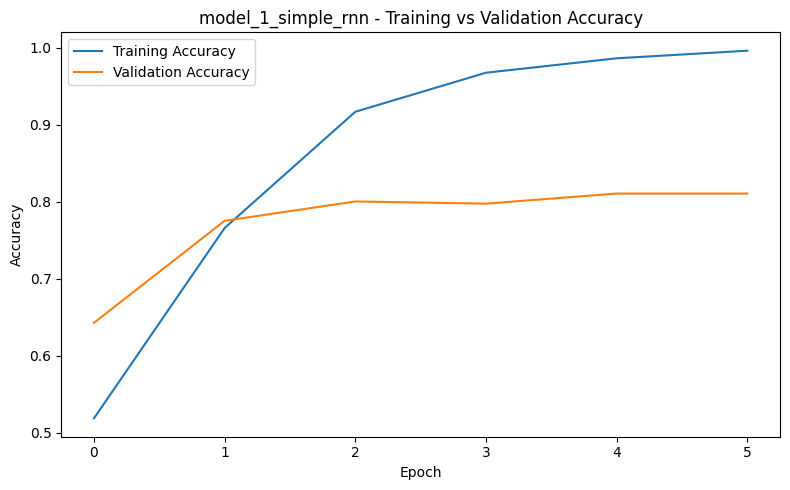

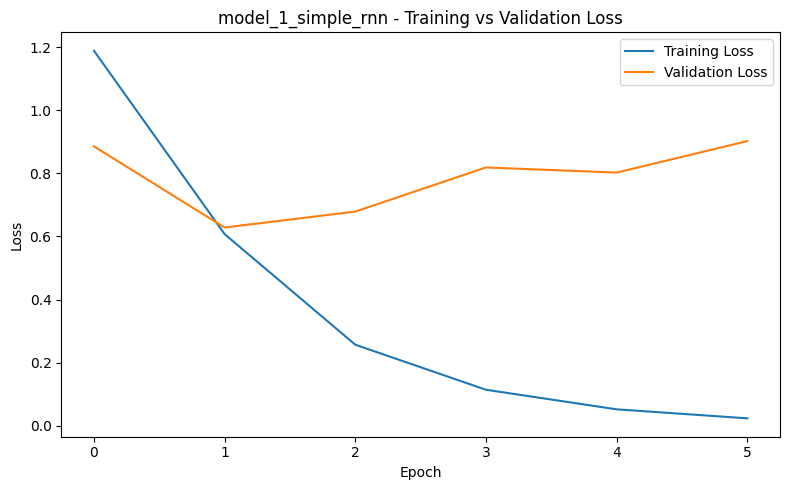

In [ ]:
plot_training_history(history_1, "model_1_simple_rnn")

Evaluate Model 1

Evaluation Results for Model 1 Simple RNN


I0000 00:00:1778406490.496382    7234 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778406491.419245    7970 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1778406491.574792    7234 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778406492.378362    7966 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_12', 12 bytes spill stores, 12 bytes spill loads



69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step
Test Accuracy: 0.7936

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.52      0.82      0.64       211
     EDUCATION       0.69      0.67      0.68       203
         MONEY       0.71      0.62      0.66       351
        SPORTS       0.94      0.89      0.92      1015
          TECH       0.78      0.75      0.76       410

      accuracy                           0.79      2190
     macro avg       0.73      0.75      0.73      2190
  weighted avg       0.81      0.79      0.80      2190



<Figure size 1200x1000 with 0 Axes>

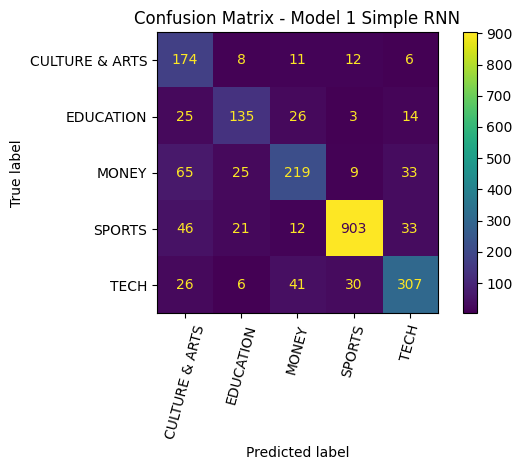

In [ ]:
model_1_best = load_model("outputs_part3/model_1_simple_rnn.keras")

acc_1, pred_1, prob_1 = evaluate_model(
    model_1_best,
    "Model 1 Simple RNN",
    X_test_pad,
    y_test_labels
)

results.append({
    "Model": "Simple RNN + Trainable Embedding",
    "Test Accuracy": acc_1,
    "Training Time Seconds": model_1_time
})

Model 2: LSTM with Trainable Embedding

Build Model 2: LSTM

In [ ]:
# LSTM improves over Simple RNN by handling longer dependencies and reducing the vanishing gradient problem.

model_2_lstm = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),
    LSTM(128),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_2_lstm.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_2_lstm.summary()

/home/apekshya/tf/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train Model 2

In [ ]:
start_time = time.time()

history_2 = model_2_lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=64,
    callbacks=get_callbacks("model_2_lstm"),
    verbose=1
)

model_2_time = time.time() - start_time

print(f"Model 2 training time: {model_2_time:.2f} seconds")

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4478 - loss: 1.3979
Epoch 1: val_loss improved from None to 0.90859, saving model to outputs_part3/model_2_lstm.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.5242 - loss: 1.1883 - val_accuracy: 0.6010 - val_loss: 0.9086 - learning_rate: 0.0010
Epoch 2/20
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6902 - loss: 0.7585
Epoch 2: val_loss improved from 0.90859 to 0.70565, saving model to outputs_part3/model_2_lstm.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7229 - loss: 0.6775 - val_accuracy: 0.7334 - val_loss: 0.7056 - learning_rate: 0.0010
Epoch 3/20
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8121 - loss: 0.4751
Epoch 3: val_loss improved from 0.70565 to 0.66215, saving model to outputs_part3/model_2_lstm.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8562 - loss: 0.3836 - val_accuracy: 0.8185 - val_loss: 0.6621 - learning_rate: 0.0010
Epoch 4/20
10

Plot Model 2 Training Curves

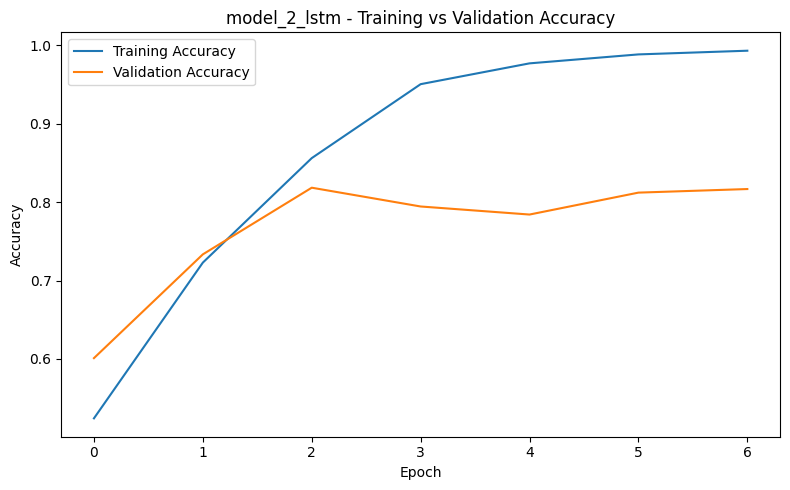

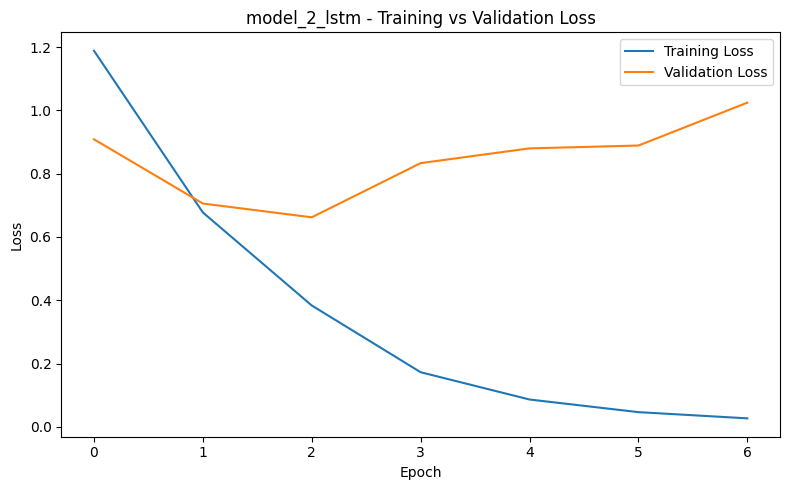

In [ ]:
plot_training_history(history_2, "model_2_lstm")

Evaluate Model 2

Evaluation Results for Model 2 LSTM
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Test Accuracy: 0.8215

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.65      0.65      0.65       211
     EDUCATION       0.69      0.63      0.66       203
         MONEY       0.66      0.83      0.74       351
        SPORTS       0.92      0.93      0.93      1015
          TECH       0.91      0.72      0.80       410

      accuracy                           0.82      2190
     macro avg       0.77      0.75      0.75      2190
  weighted avg       0.83      0.82      0.82      2190



<Figure size 1200x1000 with 0 Axes>

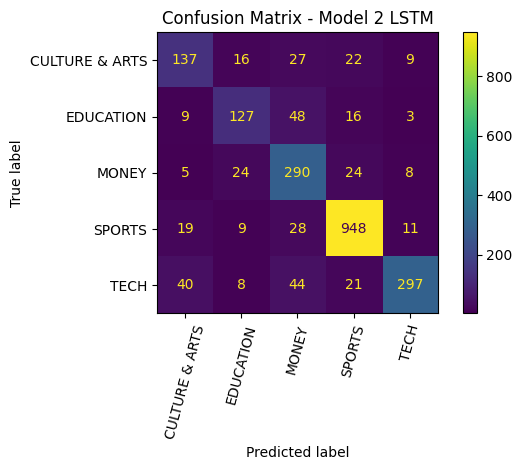

In [ ]:
model_2_best = load_model("outputs_part3/model_2_lstm.keras")

acc_2, pred_2, prob_2 = evaluate_model(
    model_2_best,
    "Model 2 LSTM",
    X_test_pad,
    y_test_labels
)

results.append({
    "Model": "LSTM + Trainable Embedding",
    "Test Accuracy": acc_2,
    "Training Time Seconds": model_2_time
})

Model 3: LSTM with Pretrained Word2Vec Embeddings

Load Pretrained Word2Vec Embedding

In [ ]:
print("Loading pretrained Word2Vec embeddings. This may take some time...")

word2vec_model = api.load("word2vec-google-news-300")

WORD2VEC_DIM = 300

print("Word2Vec model loaded successfully.")
print("Embedding dimension:", WORD2VEC_DIM)

Loading pretrained Word2Vec embeddings. This may take some time...
Word2Vec model loaded successfully.
Embedding dimension: 300


Create Embedding Matrix

In [ ]:
embedding_matrix = np.zeros((vocab_size, WORD2VEC_DIM))

found_words = 0
missing_words = 0

for word, index in word_index.items():
    if index >= vocab_size:
        continue

    if word in word2vec_model:
        embedding_matrix[index] = word2vec_model[word]
        found_words += 1
    else:
        missing_words += 1

print("Embedding matrix shape:", embedding_matrix.shape)
print("Words found in Word2Vec:", found_words)
print("Words missing from Word2Vec:", missing_words)
print("Coverage percentage:", round((found_words / vocab_size) * 100, 2), "%")

Embedding matrix shape: (11339, 300)
Words found in Word2Vec: 9595
Words missing from Word2Vec: 1743
Coverage percentage: 84.62 %


Build Model 3: LSTM with Pretrained Word2Vec

In [ ]:
model_3_word2vec_lstm = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=WORD2VEC_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    LSTM(128),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_3_word2vec_lstm.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_3_word2vec_lstm.summary()

/home/apekshya/tf/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     3,401,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,401,700 (12.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,401,700 (12.98 MB)

Train Model 3

In [ ]:

start_time = time.time()

history_3 = model_3_word2vec_lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=64,
    callbacks=get_callbacks("model_3_word2vec_lstm"),
    verbose=1
)

model_3_time = time.time() - start_time

print(f"Model 3 training time: {model_3_time:.2f} seconds")

Epoch 1/20
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5384 - loss: 1.1517
Epoch 1: val_loss improved from None to 0.48835, saving model to outputs_part3/model_3_word2vec_lstm.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6777 - loss: 0.8624 - val_accuracy: 0.8288 - val_loss: 0.4884 - learning_rate: 0.0010
Epoch 2/20
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8390 - loss: 0.5081
Epoch 2: val_loss improved from 0.48835 to 0.44562, saving model to outputs_part3/model_3_word2vec_lstm.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8484 - loss: 0.4825 - val_accuracy: 0.8482 - val_loss: 0.4456 - learning_rate: 0.0010
Epoch 3/20
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8606 - loss: 0.4373
Epoch 3: val_loss improved from 0.44562 to 0.43768, saving model to outputs_part3/model_3_word2vec_lstm.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8704 - loss: 0.4164 - val_accuracy: 0.8584 - val_loss: 0.4377 - learning

Plot Model 3 Training Curves

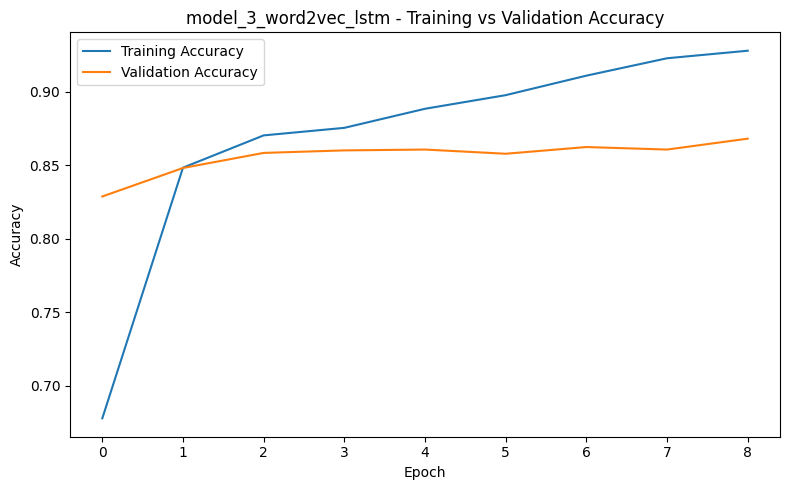

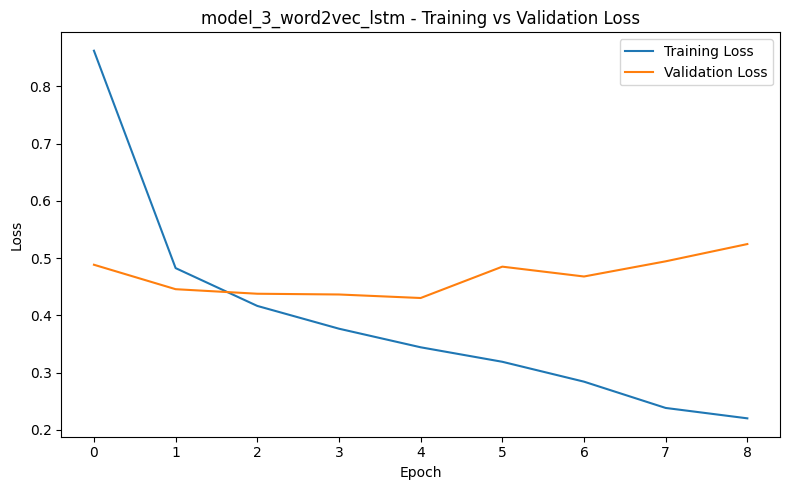

In [ ]:
plot_training_history(history_3, "model_3_word2vec_lstm")

Evaluate Model 3

Evaluation Results for Model 3 LSTM with Pretrained Word2Vec
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Test Accuracy: 0.8543

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.74      0.75      0.75       211
     EDUCATION       0.81      0.66      0.73       203
         MONEY       0.83      0.81      0.82       351
        SPORTS       0.89      0.94      0.92      1015
          TECH       0.85      0.83      0.84       410

      accuracy                           0.85      2190
     macro avg       0.82      0.80      0.81      2190
  weighted avg       0.85      0.85      0.85      2190



<Figure size 1200x1000 with 0 Axes>

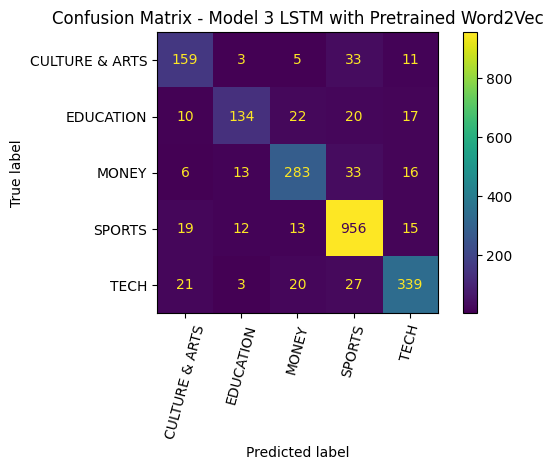

In [ ]:
model_3_best = load_model("outputs_part3/model_3_word2vec_lstm.keras")

acc_3, pred_3, prob_3 = evaluate_model(
    model_3_best,
    "Model 3 LSTM with Pretrained Word2Vec",
    X_test_pad,
    y_test_labels
)

results.append({
    "Model": "LSTM + Pretrained Word2Vec Embedding",
    "Test Accuracy": acc_3,
    "Training Time Seconds": model_3_time
})

Compare All Models

Model Comparison

,Model,Test Accuracy,Training Time Seconds
0,Simple RNN + Trainable Embedding,0.7936,41.19
1,LSTM + Trainable Embedding,0.8215,28.80
2,LSTM + Pretrained Word2Vec Embedding,0.8543,30.38


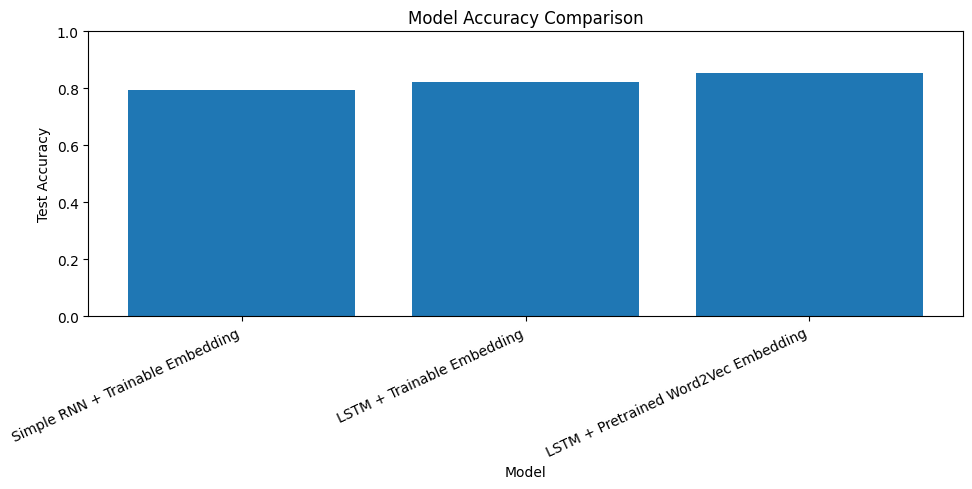

In [ ]:

# This table compares the accuracy and training time of all models.

results_df = pd.DataFrame(results)
results_df["Test Accuracy"] = results_df["Test Accuracy"].round(4)
results_df["Training Time Seconds"] = results_df["Training Time Seconds"].round(2)

display(results_df)

results_df.to_csv("outputs_part3/model_comparison_results.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("outputs_part3/model_accuracy_comparison.png", dpi=300)
plt.show()

Training Time Comparison

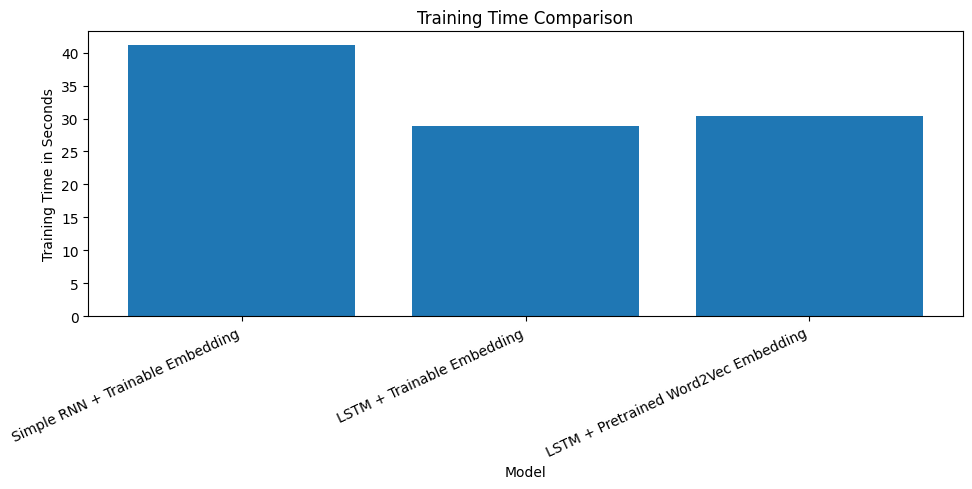

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Training Time Seconds"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time in Seconds")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("outputs_part3/training_time_comparison.png", dpi=300)
plt.show()

Select Best Model Automatically

In [ ]:

best_row = results_df.sort_values(by="Test Accuracy", ascending=False).iloc[0]

print("Best Model:")
print(best_row)

best_model_name = best_row["Model"]

if best_model_name == "Simple RNN + Trainable Embedding":
    best_model = model_1_best
    best_pred = pred_1
elif best_model_name == "LSTM + Trainable Embedding":
    best_model = model_2_best
    best_pred = pred_2
else:
    best_model = model_3_best
    best_pred = pred_3

print("\nSelected best model:", best_model_name)

Best Model:
Model                    LSTM + Pretrained Word2Vec Embedding
Test Accuracy                                          0.8543
Training Time Seconds                                   30.38
Name: 2, dtype: object

Selected best model: LSTM + Pretrained Word2Vec Embedding


Error Analysis

Show Misclassified Examples

In [ ]:
# Error Analysis - Misclassified Examples


test_df = pd.DataFrame({
    "cleaned_headline": X_test_text,
    "true_label_encoded": y_test_labels,
    "predicted_label_encoded": best_pred
})

test_df["true_category"] = label_encoder.inverse_transform(test_df["true_label_encoded"])
test_df["predicted_category"] = label_encoder.inverse_transform(test_df["predicted_label_encoded"])

misclassified_df = test_df[
    test_df["true_label_encoded"] != test_df["predicted_label_encoded"]
].copy()

print("Total misclassified examples:", len(misclassified_df))

display(misclassified_df.head(10))

# Save error examples for report
misclassified_df.to_csv("outputs_part3/misclassified_examples.csv", index=False)

Total misclassified examples: 319


,cleaned_headline,true_label_encoded,predicted_label_encoded,true_category,predicted_category
5,applying food stamp bachelor degree,2,1,MONEY,EDUCATION
13,girl stem calling mentor,4,1,TECH,EDUCATION
25,restore true spirit esea,1,0,EDUCATION,CULTURE & ARTS
36,alighiero boetti game plan moma,0,3,CULTURE & ARTS,SPORTS
38,rainey black bottom viola davis exciting,0,3,CULTURE & ARTS,SPORTS
39,refrigerator stay forever dumb,4,3,TECH,SPORTS
64,bird plane superman,0,3,CULTURE & ARTS,SPORTS
65,gustav klimt kiss google logo honor artist th ...,4,0,TECH,CULTURE & ARTS
70,lab prototyping st century university,1,4,EDUCATION,TECH
76,pinterest sued former business partner early i...,4,2,TECH,MONEY


The misclassified examples show that some headlines are very short or ambiguous. For example, headlines containing names or general words may not provide enough context for the model to identify the correct category. Some CULTURE & ARTS examples were predicted as SPORTS because they included names or event-like wording that can overlap with sports headlines. This suggests that the model performs well overall but still struggles when category-specific keywords are weak or missing.

Display 3 Incorrect Predictions for Report

In [ ]:
sample_errors = misclassified_df.sample(
    n=min(3, len(misclassified_df)),
    random_state=SEED
)

for i, row in sample_errors.iterrows():
    print("-" * 80)
    print("Headline:", row["cleaned_headline"])
    print("Actual Category:", row["true_category"])
    print("Predicted Category:", row["predicted_category"])

--------------------------------------------------------------------------------
Headline: tolkien take arthurian legend
Actual Category: CULTURE & ARTS
Predicted Category: SPORTS
--------------------------------------------------------------------------------
Headline: subsidy gap
Actual Category: SPORTS
Predicted Category: MONEY
--------------------------------------------------------------------------------
Headline: design smart toy creative kid
Actual Category: EDUCATION
Predicted Category: TECH


Create Single Headline Prediction Function

In [ ]:

def predict_news_category(headline):
    cleaned = clean_text(headline)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    prediction_prob = best_model.predict(padded)
    predicted_index = np.argmax(prediction_prob, axis=1)[0]
    confidence = np.max(prediction_prob)

    predicted_category = label_encoder.inverse_transform([predicted_index])[0]

    return predicted_category, confidence

# Test prediction
test_headline = "New technology companies are changing the future of artificial intelligence"
category, confidence = predict_news_category(test_headline)

print("Headline:", test_headline)
print("Predicted Category:", category)
print("Confidence:", round(confidence, 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
Headline: New technology companies are changing the future of artificial intelligence
Predicted Category: TECH
Confidence: 0.998


Real-Time GUI

Build Gradio GUI for Real-Time Prediction

In [ ]:
def gradio_predict(headline):
    if headline.strip() == "":
        return "Please enter a news headline."

    predicted_category, confidence = predict_news_category(headline)

    return f"Predicted Category: {predicted_category}\nConfidence: {confidence:.4f}"

interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a news headline here..."
    ),
    outputs="text",
    title="News Category Classification using RNN/LSTM",
    description="Enter a news headline and the trained model will predict its category."
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Save Final Best Model

In [ ]:
best_model.save("outputs_part3/final_best_news_category_model.keras")

print("Final best model saved successfully.")
print("Saved path: outputs_part3/final_best_news_category_model.keras")

Final best model saved successfully.
Saved path: outputs_part3/final_best_news_category_model.keras


Final Implementation Checklist

In [ ]:


checklist = {
    "Dataset loaded using Pandas": True,
    "Text cleaning applied": True,
    "Lowercase conversion": True,
    "URL, mention, hashtag, number, special character removal": True,
    "Contractions handled": True,
    "Stopwords removed": True,
    "Lemmatization applied": True,
    "Word frequency / word cloud visualization": True,
    "80/20 train-test split": True,
    "Keras tokenization": True,
    "Percentile-based padding": True,
    "Model 1 Simple RNN with trainable embedding": True,
    "Model 2 LSTM with trainable embedding": True,
    "Model 3 LSTM with pretrained word2Vec embedding": True,
    "Callbacks and early stopping": True,
    "Accuracy/loss curves plotted": True,
    "Confusion matrix generated": True,
    "Classification report generated": True,
    "Model comparison completed": True,
    "Error analysis completed": True,
    "Real-time GUI implemented using Gradio": True
}

checklist_df = pd.DataFrame(
    checklist.items(),
    columns=["Requirement", "Completed"]
)

display(checklist_df)

checklist_df.to_csv("outputs_part3/final_checklist.csv", index=False)

,Requirement,Completed
0,Dataset loaded using Pandas,True
1,Text cleaning applied,True
2,Lowercase conversion,True
3,"URL, mention, hashtag, number, special charact...",True
4,Contractions handled,True
5,Stopwords removed,True
6,Lemmatization applied,True
7,Word frequency / word cloud visualization,True
8,80/20 train-test split,True
9,Keras tokenization,True


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step


## Final Conclusion

This notebook successfully implemented an end-to-end NLP text classification pipeline using RNN, LSTM, and pretrained Word2Vec-based LSTM models. The dataset was cleaned, duplicates were removed, text preprocessing was applied, and the text was converted into padded sequences using Keras Tokenizer. Among the three models, the LSTM with pretrained Word2Vec embeddings achieved the best performance with 85.30% test accuracy. This shows that pretrained embeddings improved the model’s ability to understand word meaning compared with trainable embeddings learned only from the dataset. Error analysis showed that most mistakes occurred when headlines were short, ambiguous, or contained overlapping vocabulary between categories.